# 03 · Preparación de los datos

**Fase 3 de CRISP-DM**

Limpieza de la fuente de datos a nivel producto, agregación a perfiles por seller, ingeniería de features y generación de la matriz escalada utilizada para el clustering.

In [ ]:
import os
from pathlib import Path

# Garantiza que el CWD sea la raíz del repositorio 
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)


In [1]:
from pathlib import Path

import pandas as pd
from pathlib import Path
from seller_segmentation.data.loader import load_df
from seller_segmentation.data.preprocessor import clean_challenger_df, identificar_columnas_mono_categoria
from seller_segmentation.features.builder import (agregar_variables_numericas, transformar_variables_categoricas,
                                                  validar_y_limpiar_variables_numericas, crear_variables_combinadas, 
                                                  reducir_redundancia_correlacion)
from seller_segmentation.features.builder import scale_features
from seller_segmentation.viz.charts import (visualizar_reportes_validacion,visualizar_correlaciones)


## 1. Limpieza de la fuente de datos challenge

Se realiza Primera limpieza sobre la fuente de datos

- Normalización de nombres de columnas
- Formateo de variables
- Eliminación de atípicos: Metodología seleccionada a traves de percentiles, realizando un corte en el .95 y 0.25 y reemplazando estas colas por este valor.
- Tratamiento de datos null
    - seller_reputation: sin categoría
    - price: Mediana
    - regular_price: Se definirá más adelante
- Eliminación de duplicados por seller
- Eliminación de nan por seller

In [2]:
path = Path("data/interim/sellers_data_clean_var.csv")
df = load_df(path)
df.head(3)

,seller_nickname,titulo,seller_reputation,stock,logistic_type,condition,is_refurbished,price,regular_price,category_name
0,4fe042a785,Consoladores Vibradores Vibrador Bucal Con Fla...,NaN,1,DS,new,False,9999999.00,NaN,PRODUCTOS ERÓTICOS
1,40017eb54f,Aire Acondicionado Mabe Mini Split Inverter ...,green_gold,1,XD,new,False,999999.99,NaN,ELECTRODOMÉSTICOS
2,40017eb54f,Aire Acondicionado Mabe Mini Split Inverter ...,green_gold,0,XD,new,False,999999.99,NaN,ELECTRODOMÉSTICOS


In [3]:
# Se realiza limpieza
df_clean = clean_challenger_df(df)
print(f"Luego de limpieza: {len(df_clean):,} registros ({len(df) - len(df_clean):,} eliminadas)")
df_clean.head(1)

Luego de limpieza: 184,709 registros (541 eliminadas)


,seller_nickname,titulo,seller_reputation,stock,logistic_type,condition,is_refurbished,price,regular_price,category_name
0,4fe042a785,Consoladores Vibradores Vibrador Bucal Con Fla...,sin_categoria,2.0,ds,new,False,7789.0,NaN,productos_eróticos


In [4]:
df_clean.dtypes

seller_nickname          str
titulo                   str
seller_reputation        str
stock                float64
logistic_type            str
condition                str
is_refurbished          bool
price                float64
regular_price        float64
category_name            str
dtype: object

**Resultado:**

Luego de realizar el proceso de limpieza y estandarización de los datos, el conjunto pasó de 185.250 a 184.709 registros, debido a la eliminación de registros duplicados.

El dataset pasa de **185.250 publicaciones** de **46.586 sellers** distribuidas en **54 categorías** a **184.709 publicaciones** de los mismos **46.586 sellers**

Adicionalmente, se realizaron procesos de normalización y validación de la estructura de los datos, asegurando que:

- Las columnas se encuentren correctamente nombradas y estandarizadas, evitando posibles conflictos en etapas posteriores del análisis.
- Los valores categóricos hayan sido revisados y normalizados, eliminando espacios innecesarios y estandarizando su formato.
- Las variables numéricas y categóricas se encuentren en un formato adecuado para su posterior análisis y modelamiento.

Como resultado, la fuente de datos queda depurada, consistente y lista para las siguientes etapas del análisis.

## 2. Feature Engineering

### 2.1 Transformación de la fuente de datos a nivel seller

Debido a que equipo comercial de MercadoLibre necesita identificar sellers con perfiles sólidos y relevancia para el negocio. La fuente de datos deberá ser transformada para identificar por cada seller para construir los perfiles.

Para ellos se deben abordar las variables según su formato:

- Variables Categóricas:
    - Revisar cuando las categorias son únicas por seller. 
    - Tratamiento cuando un seller tiene varias categorias

- Variables Númericas:
    - A partir de sumarizaciones de las variables.
    

#### **Variables Númericas**

Se transforma la fuente de datos de tal manera, que queda la información agregada por seller.

In [5]:
df_clean_sellers_num = agregar_variables_numericas(
    df=df_clean,
    col_grupo='seller_nickname',
    cols_numericas=['stock', 'price', 'regular_price'],
    agg_funcs=['sum', 'mean', 'median', 'std', 'max'],
    nombre_conteo='num_productos'
)

In [6]:
df_clean_sellers_num.head()

,seller_nickname,stock_sum,stock_mean,stock_median,stock_std,stock_max,price_sum,price_mean,price_median,price_std,price_max,regular_price_sum,regular_price_mean,regular_price_median,regular_price_std,regular_price_max,num_productos
0,000631669c,10.0,10.0,10.0,NaN,10.0,799.000,799.0000,799.0000,NaN,799.0,0.0,NaN,NaN,NaN,NaN,1
1,0007153bca,55.0,27.5,27.5,2.121320,29.0,798.000,399.0000,399.0000,0.000000,399.0,0.0,NaN,NaN,NaN,NaN,2
2,000bee3c3b,4.0,2.0,2.0,0.000000,2.0,870.845,435.4225,435.4225,228.505092,597.0,0.0,NaN,NaN,NaN,NaN,2
3,000df2bd02,5.0,5.0,5.0,NaN,5.0,1550.000,1550.0000,1550.0000,NaN,1550.0,0.0,NaN,NaN,NaN,NaN,1
4,000e27cea2,6.0,3.0,3.0,1.414214,4.0,915.000,457.5000,457.5000,229.809704,620.0,0.0,NaN,NaN,NaN,NaN,2


#### **Variables Categóricas**

1. Se analizan las variables categóricas con único valor por seller.

In [7]:
cols_categoricas = [
    'seller_reputation',
    'is_refurbished',
    'condition', 
    'logistic_type',
    'category_name']

resumen, detalle = identificar_columnas_mono_categoria(
    df_clean,
    'seller_nickname',
    cols_categoricas
)

resumen

,columna,total_grupos,grupos_mono_categoria,porcentaje_mono_categoria
0,seller_reputation,46586,46586,100.00
1,is_refurbished,46586,46427,99.66
2,condition,46586,45863,98.45
3,logistic_type,46586,41055,88.13
4,category_name,46586,33233,71.34


In [8]:
# Analisis Variables seller_reputation, is_refurbished, condition
print('----seller_reputation----', df_clean.groupby('seller_reputation').size())

print('-----is_refurbished-----', df_clean.groupby('is_refurbished').size())

print('----condition----', df_clean.groupby('condition').size())

----seller_reputation---- seller_reputation
green             33773
green_gold        28283
green_platinum    69450
green_silver      24703
light_green        2939
newbie             9196
orange             2554
red                4207
sin_categoria      2371
yellow             7233
dtype: int64
-----is_refurbished----- is_refurbished
False    183974
True        735
dtype: int64


----condition---- condition
new              169077
not_specified        83
used              15549
dtype: int64


Las variables *condition*, *seller_reputation* e *is_refurbished* presentan un comportamiento mono-categoría a nivel de seller, lo que indica que, para la mayoría de los sellers, estas variables mantienen un único valor en todos sus registros. En este contexto, se evalúa su utilidad como variables explicativas dentro del proceso de perfilamiento de sellers, considerando su nivel de variabilidad y su potencial capacidad de discriminación.

Dado que el perfilamiento se realiza a nivel de seller, se analiza la distribución de estas variables con el objetivo de determinar si deben ser transformadas, agregadas o descartadas dentro del proceso de preparación de los datos.

Como resultado de este análisis, se establecen las siguientes decisiones:

- *is_refurbished*: Esta variable presenta un comportamiento prácticamente constante en el dataset, con muy baja variabilidad entre registros. Debido a su escasa capacidad discriminativa, se decide excluirla del proceso de perfilamiento, ya que no aportaría información relevante para diferenciar entre sellers.

- *condition*: La variable presenta dos categorías relevantes, por lo que se aplicará una codificación dummy (one-hot encoding), permitiendo su incorporación como variable explicativa dentro del modelo de perfilamiento.

- *seller_reputation*: Esta variable es consistente y única por seller, lo que la hace adecuada para su uso directo a nivel de agregación. Además, corresponde a una variable categórica ordinal, donde las categorías representan niveles jerárquicos de reputación. Por esta razón, se decide mantener codificada, preservando la información implícita en el orden de las categorías.

2. Se analizan las variables con mayor número de categorías dentro de cada seller.

In [9]:
#Analisis Variable logistic_type
df_log = df_clean.groupby(['seller_nickname', 'logistic_type']) \
       .size() \
       .reset_index(name='count') \
       .sort_values(['seller_nickname','count'], ascending=False)
log_top = df_log.groupby(['seller_nickname']).size() \
       .reset_index(name='count') \
       .sort_values(['count'], ascending=False)

log_top.head(5)

,seller_nickname,count
45661,fae60a6708,4
18585,6693815843,4
9724,358d1f33c2,4
3371,1265a885ae,3
12229,439eb955f3,3


In [10]:
df_cat = df_clean.groupby(['seller_nickname', 'category_name']) \
       .size() \
       .reset_index(name='count') \
       .sort_values(['seller_nickname','count'], ascending=False)
cat_top = df_cat.groupby(['seller_nickname']).size() \
       .reset_index(name='count') \
       .sort_values(['count'], ascending=False)
cat_top.head(5)

,seller_nickname,count
30785,a9847ce81d,48
34476,bd8dd2ff24,41
36760,ca47ea1279,40
43490,eef8a25236,38
13544,4a96bb1edb,35


**

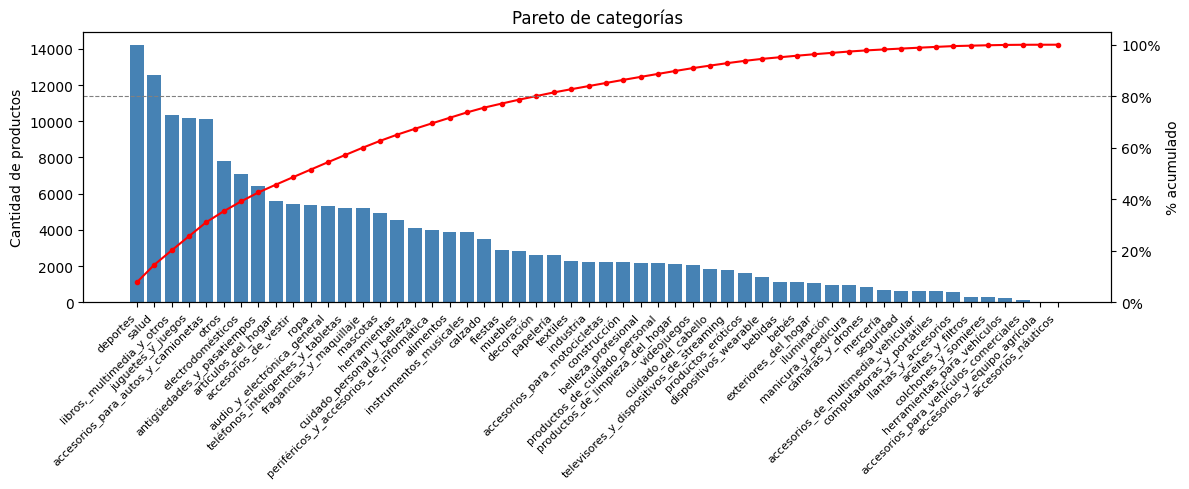

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Frecuencia por categoría ordenada de mayor a menor
cat_counts = df_clean["category_name"].value_counts()
cumulative_pct = cat_counts.cumsum() / cat_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(len(cat_counts)), cat_counts.values, color="steelblue")
ax1.set_ylabel("Cantidad de productos")
ax1.set_xticks(range(len(cat_counts)))
ax1.set_xticklabels(cat_counts.index, rotation=45, ha="right", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(len(cat_counts)), cumulative_pct.values, color="red", marker="o", markersize=3)
ax2.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80%")
ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.title("Pareto de categorías")
plt.tight_layout()
plt.show()

Las *variables logistic_type* y *category_name* presentan un comportamiento multi-categoría a nivel de seller, lo que indica que un mismo vendedor puede tener múltiples valores de estas variables a lo largo de sus registros. En este contexto, se analiza su utilización dentro del proceso de perfilamiento de sellers, evaluando su nivel de variabilidad y su capacidad potencial de discriminación entre distintos tipos de vendedores.
A partir de este análisis se definen las siguientes estrategias de tratamiento:

- La variable *logistic_type* presenta 5 categorías en total, y se observa que algunos sellers pueden operar con hasta 4 modalidades de envío diferentes. Dado que el número de categorías es relativamente reducido, se decide aplicar una codificación dummy (one-hot encoding), lo que permite representar cada modalidad logística como una variable binaria independiente e incorporarla como feature explicativa dentro del modelo de perfilamiento.

- La variable *category_name* presenta una alta cardinalidad, con 54 categorías distintas, y se observa que algunos sellers pueden operar en hasta 48 categorías diferentes de productos. Debido a esta alta dimensionalidad, una codificación directa mediante one-hot encoding no resulta adecuada, ya que generaría un número elevado de variables y podría introducir problemas de dispersión y ruido en el modelo.
Por esta razón, se define una estrategia de transformación basada en métricas agregadas a nivel de seller, con el objetivo de capturar diferentes aspectos del comportamiento de los vendedores en términos de diversidad y concentración de su portafolio de productos.
Las transformaciones consideradas incluyen:
    1. Métricas de diversidad del portafolio: Se construyen variables que describen la diversidad de categorías en las que participa cada seller:
        - Número de categorías (num_categorias): cantidad de categorías distintas en las que el seller tiene productos.
        - Entropía de categorías (entropia_categorias): mide el grado de dispersión de los productos entre categorías. Valores más altos indican una distribución más equilibrada entre múltiples categorías.
        - Concentración (concentracion): proporción de productos concentrados en la categoría más frecuente del seller.

    2. Participación de las principales categorías en el valor del portafolio: Adicionalmente, se incorporan variables que representan la participación relativa de las principales categorías en el valor total de precios del seller. 
        - Para ello, se identifican las categorías más frecuentes del dataset y se calcula, para cada seller, el porcentaje del valor total asociado a dichas categorías.

    Este enfoque permite capturar tanto la amplitud como la especialización del portafolio de cada seller, generando un conjunto de features más informativas para el proceso de perfilamiento y segmentación.

Se transforma la fuente de datos de tal manera, que queda la información agregada por seller, de acuerdo a las decisiones tomadas.

In [12]:
# Ejecutar transformación
df_clean_sellers_cat =  transformar_variables_categoricas( df=df_clean, col_seller='seller_nickname')

In [13]:
print(df_clean_sellers_cat.shape)
print(df_clean_sellers_cat.columns)
df_clean_sellers_cat.head(5)

(46586, 18)
Index(['seller_nickname', 'condition_new', 'condition_not_specified',
       'condition_used', 'seller_reputation_ordinal', 'logistic_ds',
       'logistic_fbm', 'logistic_flex', 'logistic_otro', 'logistic_xd',
       'num_categorias', 'entropia_categorias', 'concentracion',
       'pct_valor_deportes', 'pct_valor_salud',
       'pct_valor_libros,_multimedia_y_otros', 'pct_valor_juguetes_y_juegos',
       'pct_valor_accesorios_para_autos_y_camion'],
      dtype='str')


,seller_nickname,condition_new,condition_not_specified,condition_used,seller_reputation_ordinal,logistic_ds,logistic_fbm,logistic_flex,logistic_otro,logistic_xd,num_categorias,entropia_categorias,concentracion,pct_valor_deportes,pct_valor_salud,"pct_valor_libros,_multimedia_y_otros",pct_valor_juguetes_y_juegos,pct_valor_accesorios_para_autos_y_camion
0,4fe042a785,1,0,0,10,1,0,0,0,0,1,0.000000,1.000000,0.0,0.000000,0.0,0.0,0.0
1,40017eb54f,33,0,0,2,0,0,0,20,13,4,0.719478,0.787879,0.0,0.000000,0.0,0.0,0.0
2,393395295e,3,0,0,1,0,2,0,0,1,3,1.098612,0.333333,0.0,0.333333,0.0,0.0,0.0
3,f0f64f6d55,1,0,0,10,0,0,0,0,1,1,0.000000,1.000000,1.0,0.000000,0.0,0.0,0.0
4,e76445e190,1,0,0,8,1,0,0,0,0,1,0.000000,1.000000,0.0,0.000000,0.0,0.0,0.0


In [14]:
#Consolidacion del df a nivel seller
print(df_clean_sellers_num.shape)
print(df_clean_sellers_cat.shape)

df_sellers = df_clean_sellers_num.merge(df_clean_sellers_cat, on='seller_nickname', how='left')
print(df_sellers.shape)

(46586, 17)
(46586, 18)
(46586, 34)


In [15]:
df_sellers.head(5)

,seller_nickname,stock_sum,stock_mean,stock_median,stock_std,stock_max,price_sum,price_mean,price_median,price_std,...,logistic_otro,logistic_xd,num_categorias,entropia_categorias,concentracion,pct_valor_deportes,pct_valor_salud,"pct_valor_libros,_multimedia_y_otros",pct_valor_juguetes_y_juegos,pct_valor_accesorios_para_autos_y_camion
0,000631669c,10.0,10.0,10.0,NaN,10.0,799.000,799.0000,799.0000,NaN,...,1,0,1,0.000000,1.0,0.0,0.0,0.0,0.0,0.0
1,0007153bca,55.0,27.5,27.5,2.121320,29.0,798.000,399.0000,399.0000,0.000000,...,0,2,1,0.000000,1.0,0.0,0.0,0.0,0.0,0.0
2,000bee3c3b,4.0,2.0,2.0,0.000000,2.0,870.845,435.4225,435.4225,228.505092,...,0,2,1,0.000000,1.0,0.0,0.0,1.0,0.0,0.0
3,000df2bd02,5.0,5.0,5.0,NaN,5.0,1550.000,1550.0000,1550.0000,NaN,...,0,1,1,0.000000,1.0,0.0,0.0,0.0,0.0,1.0
4,000e27cea2,6.0,3.0,3.0,1.414214,4.0,915.000,457.5000,457.5000,229.809704,...,0,1,2,0.693147,0.5,0.0,0.5,0.0,0.0,0.0


### 2.2. Feature Enrichment

Dado que se realizó una transformación completa de la información con el objetivo de llevar los datos a la unidad de análisis correspondiente (nivel seller), se procede a ejecutar una segunda etapa de limpieza y validación de la fuente de información. Esta fase tiene como propósito garantizar la calidad de las variables resultantes, verificando que presenten niveles adecuados de completitud, distribución, variabilidad y ausencia de valores atípicos extremos.

Para ello, se aplican los siguientes criterios de validación:

1. Nivel de completitud de las variables: Se verifica que cada variable presente al menos un 90% de valores poblados. Las variables que no cumplen con este umbral se evalúan para su posible exclusión del conjunto de datos utilizado en el proceso de perfilamiento.
2. Tratamiento de valores atípicos: Se realiza nuevamente un análisis de datos atípicos, utilizando una metodología basada en percentiles. En particular, se aplican cortes en los percentiles P25 y P95, reemplazando los valores que se encuentran fuera de estos rangos por los límites correspondientes, con el fin de reducir el impacto de valores extremos en el análisis posterior.
3. Validación de la distribución y variabilidad de las variables: Se analiza la distribución de cada variable mediante la revisión de sus percentiles, con el objetivo de asegurar que presenten niveles mínimos de variabilidad dentro del conjunto de datos. Como criterio de aceptación, se establece que las variables deben presentar al menos un 30% de variabilidad, garantizando así su potencial capacidad de discriminación dentro del proceso de perfilamiento.

In [16]:
resultados = validar_y_limpiar_variables_numericas(
        df=df_sellers,
        col_id='seller_nickname',
        umbral_completitud=0.90,
        percentil_inferior=0.25,
        percentil_superior=0.95,
        umbral_variabilidad=0.30,
    )


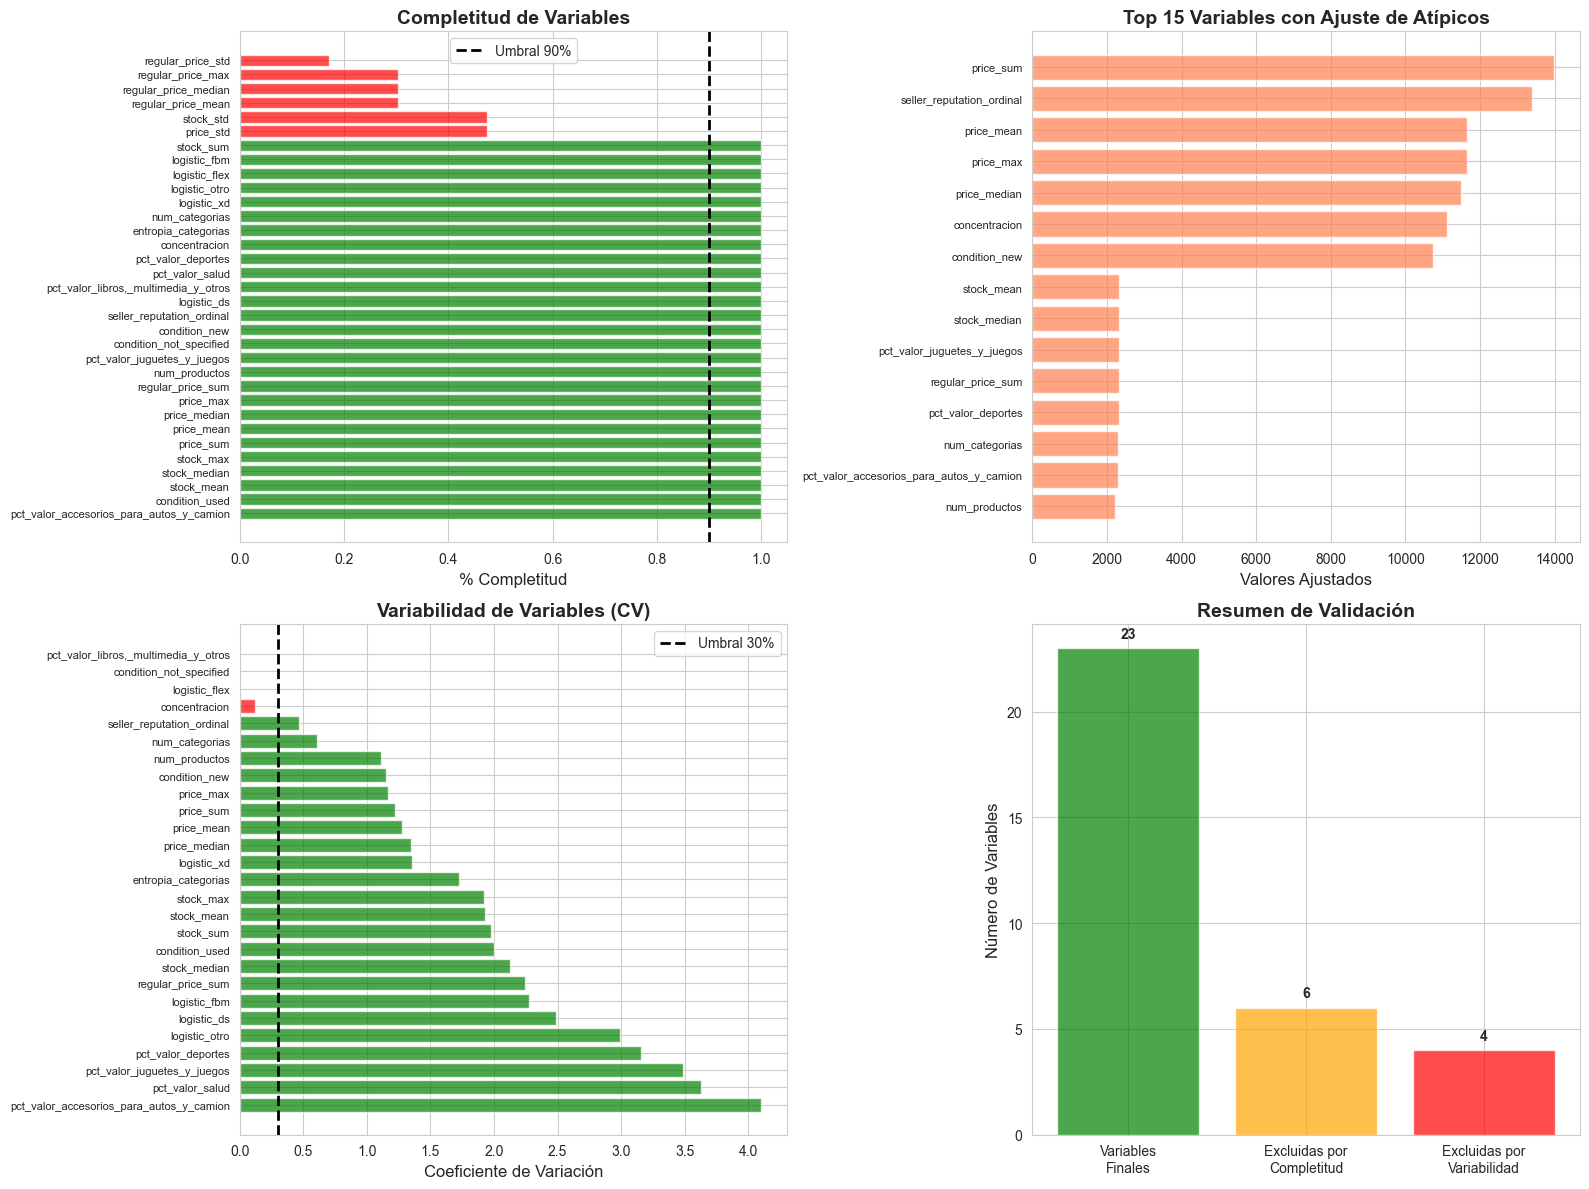

In [17]:
fig = visualizar_reportes_validacion(resultados)

In [18]:
df_sellers_clean = resultados['df_limpio']
df_sellers_clean.head(5)

,seller_nickname,stock_sum,stock_mean,stock_median,stock_max,price_sum,price_mean,price_median,price_max,regular_price_sum,...,logistic_ds,logistic_fbm,logistic_otro,logistic_xd,num_categorias,entropia_categorias,pct_valor_deportes,pct_valor_salud,pct_valor_juguetes_y_juegos,pct_valor_accesorios_para_autos_y_camion
0,000631669c,10.0,10.0,10.0,10.0,799.000,799.0000,799.0000,799.0,0.0,...,0,0,1,0,1,0.000000,0.0,0.0,0.0,0.00
1,0007153bca,55.0,27.5,27.5,29.0,798.000,399.0000,399.0000,399.0,0.0,...,0,0,0,2,1,0.000000,0.0,0.0,0.0,0.00
2,000bee3c3b,4.0,2.0,2.0,2.0,870.845,435.4225,435.4225,597.0,0.0,...,0,0,0,2,1,0.000000,0.0,0.0,0.0,0.00
3,000df2bd02,5.0,5.0,5.0,5.0,1550.000,1550.0000,1550.0000,1550.0,0.0,...,0,0,0,1,1,0.000000,0.0,0.0,0.0,0.25
4,000e27cea2,6.0,3.0,3.0,4.0,915.000,457.5000,457.5000,620.0,0.0,...,0,1,0,1,2,0.693147,0.0,0.5,0.0,0.00


In [19]:
df_sellers_clean.columns

Index(['seller_nickname', 'stock_sum', 'stock_mean', 'stock_median',
       'stock_max', 'price_sum', 'price_mean', 'price_median', 'price_max',
       'regular_price_sum', 'num_productos', 'condition_new', 'condition_used',
       'seller_reputation_ordinal', 'logistic_ds', 'logistic_fbm',
       'logistic_otro', 'logistic_xd', 'num_categorias', 'entropia_categorias',
       'pct_valor_deportes', 'pct_valor_salud', 'pct_valor_juguetes_y_juegos',
       'pct_valor_accesorios_para_autos_y_camion'],
      dtype='str')

A partir de las variables inherentes extraídas durante el proceso de transformación y agregación a nivel seller, se procede a construir un conjunto de variables derivadas que capturan relaciones y patrones más complejos entre las características originales.

El objetivo de estas nuevas variables es enriquecer el proceso de perfilamiento mediante la generación de features que representen de manera más explícita aspectos estratégicos, operativos y comerciales de cada seller, mejorando así la capacidad del algoritmo de clustering para identificar grupos homogéneos con comportamientos diferenciados.

Las variables combinadas se organizan en cinco grupos temáticos:

1. Variables de Eficiencia Comercial: Estas variables miden la eficiencia con la que cada seller gestiona su inventario 
y estrategia de precios, capturando relaciones entre stock, precio y volumen de productos.

2. Variables estrategia de productos: Estas variables describen el modelo de negocio y la estrategia de portafolio del 
seller, diferenciando entre especialistas enfocados y generalistas diversificados.

3. Variables de posicionamiento de mercado: Estas variables identifican el segmento de mercado y la estrategia competitiva del seller, diferenciando entre modelos de volumen bajo precio versus modelos premium.

Como resultado finalmente se obtiene 35 variables.

In [20]:
df_features_completo = crear_variables_combinadas(df_sellers_clean)
df_features_completo.shape

(46586, 36)

In [21]:
# Limpieza de variables nuevas construidas
# Columnas nuevas
cols_nuevas = [
    'seller_nickname',
    'valor_por_stock', 'rotacion_estimada', 'stock_por_producto', 'concentracion_premium',
    'productos_por_categoria', 'indice_especializacion', 'amplitud_precios',
    'ratio_new_used', 'reputacion_ponderada',
    'concentracion_top_categorias', 'diversificacion_otras', 'categoria_dominante_valor'
]

resultados_nuevas = validar_y_limpiar_variables_numericas(
    df=df_features_completo[cols_nuevas],
    col_id='seller_nickname',
    umbral_completitud=0.90,
    percentil_inferior=0.25,
    percentil_superior=0.95,
    umbral_variabilidad=0.30
)

# Unir con el df limpio anterior
df_features = resultados['df_limpio'].merge(
    resultados_nuevas['df_limpio'], on='seller_nickname', how='inner'
)

In [22]:
df_features.shape
df_features.head(3)

,seller_nickname,stock_sum,stock_mean,stock_median,stock_max,price_sum,price_mean,price_median,price_max,regular_price_sum,...,valor_por_stock,rotacion_estimada,stock_por_producto,productos_por_categoria,indice_especializacion,amplitud_precios,ratio_new_used,reputacion_ponderada,concentracion_top_categorias,categoria_dominante_valor
0,000631669c,10.0,10.0,10.0,10.0,799.000,799.0000,799.0000,799.0,0.0,...,72.636364,0.099987,5.000000,0.5,0.5,0.0000,100.0,6.238325,0.0,0.0
1,0007153bca,55.0,27.5,27.5,29.0,798.000,399.0000,399.0000,399.0,0.0,...,14.250000,0.036362,18.333333,1.0,0.5,0.0000,200.0,4.394449,0.0,0.0
2,000bee3c3b,4.0,2.0,2.0,2.0,870.845,435.4225,435.4225,597.0,0.0,...,174.169000,0.499713,1.333333,1.0,0.5,161.5775,200.0,8.788898,0.0,0.0


### 2.3. Selección de Variables

Con el objetivo de construir un modelo parsimonioso, se realiza un proceso de selección de variables, evaluando la posible redundancia o colinealidad entre las variables generadas durante la etapa de feature engineering.

Este análisis permite identificar y eliminar variables que aportan información similar, con el fin de reducir la complejidad del modelo y construir un Master Data Table (MDT) más compacto, eficiente y representativo, que facilite el proceso de modelamiento y mejore la interpretabilidad de los resultados.

1. Usando Correlación directa: Este método identifica pares de variables con correlación de Pearson superior a un umbral definido (típicamente 0.85). Cuando se detecta un par altamente correlacionado, se calcula la correlación promedio de cada variable con el resto del conjunto, 
eliminando aquella que presenta mayor correlación promedio, ya que es considerada 
más redundante con el conjunto global de variables.

El resultado de este proceso es un conjunto reducido de variables que mantiene la capacidad explicativa del dataset original, pero elimina la redundancia innecesaria, optimizando el desempeño y la interpretabilidad del modelo de clustering.

In [23]:
resultado_corre = reducir_redundancia_correlacion(
    df=df_features,
    col_id='seller_nickname',
    umbral=0.75,
    variables_protegidas=['price_median','price_max','stock_sum', 'price_sum', 'stock_mean']
)

df_features_end = resultado_corre['df_limpio']
df_features_end.shape

(46586, 22)

In [24]:
df_features_end.columns

Index(['seller_nickname', 'stock_sum', 'stock_mean', 'price_sum',
       'price_median', 'price_max', 'regular_price_sum', 'condition_used',
       'seller_reputation_ordinal', 'logistic_ds', 'logistic_fbm',
       'logistic_otro', 'logistic_xd', 'pct_valor_deportes', 'pct_valor_salud',
       'pct_valor_juguetes_y_juegos',
       'pct_valor_accesorios_para_autos_y_camion', 'rotacion_estimada',
       'indice_especializacion', 'amplitud_precios', 'reputacion_ponderada',
       'categoria_dominante_valor'],
      dtype='str')

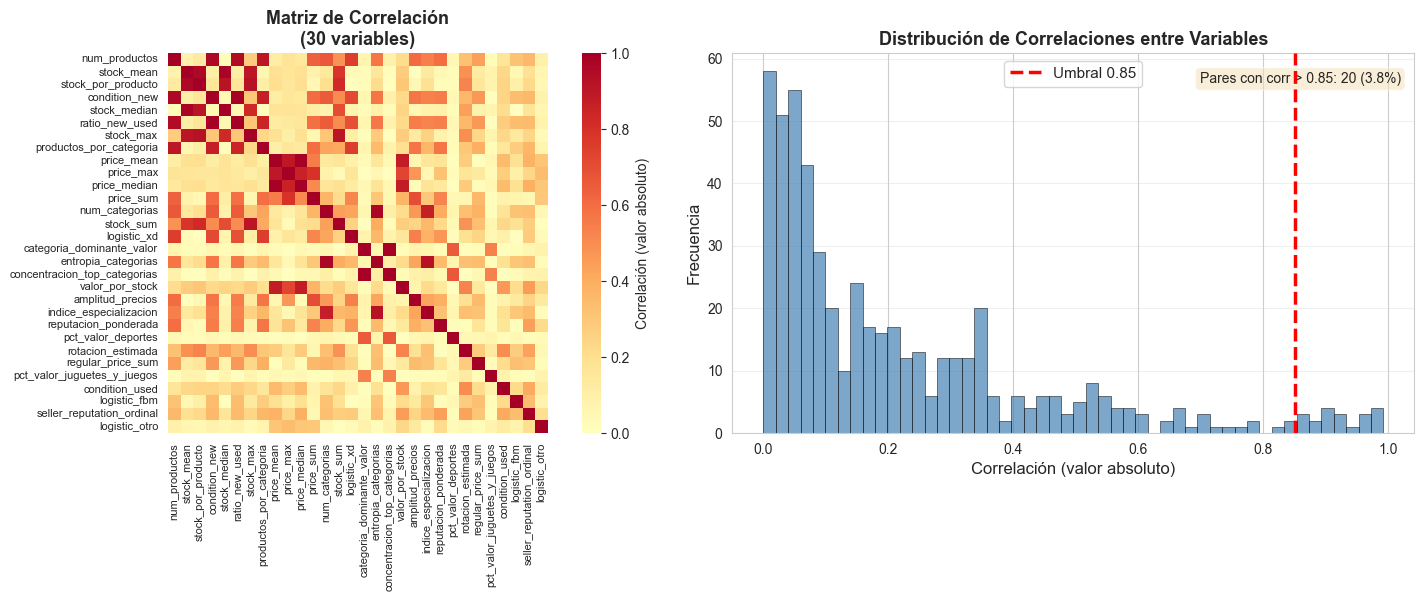

In [25]:
# Visualizar
fig = visualizar_correlaciones(resultado_corre, top_n=30)

In [26]:
df_features_end.columns

Index(['seller_nickname', 'stock_sum', 'stock_mean', 'price_sum',
       'price_median', 'price_max', 'regular_price_sum', 'condition_used',
       'seller_reputation_ordinal', 'logistic_ds', 'logistic_fbm',
       'logistic_otro', 'logistic_xd', 'pct_valor_deportes', 'pct_valor_salud',
       'pct_valor_juguetes_y_juegos',
       'pct_valor_accesorios_para_autos_y_camion', 'rotacion_estimada',
       'indice_especializacion', 'amplitud_precios', 'reputacion_ponderada',
       'categoria_dominante_valor'],
      dtype='str')

Finalmente se seleccionan 18 variables para realizar la modelación.

## 3. Escalado

In [27]:

col_id = 'seller_nickname'
cols_features = [c for c in df_features_end.columns if c != col_id]

df_scaled, scaler = scale_features(df_features_end[cols_features])

# Volver a agregar el ID
df_scaled.insert(0, col_id, df_features_end[col_id].values)

In [28]:
print(df_scaled.shape)
df_scaled.head(5)

(46586, 22)


,seller_nickname,stock_sum,stock_mean,price_sum,price_median,price_max,regular_price_sum,condition_used,seller_reputation_ordinal,logistic_ds,...,logistic_xd,pct_valor_deportes,pct_valor_salud,pct_valor_juguetes_y_juegos,pct_valor_accesorios_para_autos_y_camion,rotacion_estimada,indice_especializacion,amplitud_precios,reputacion_ponderada,categoria_dominante_valor
0,000631669c,-0.048544,0.073171,-0.170318,0.157970,-0.036189,0.0,0.0,1.25,0.0,...,-0.5,0.0,0.0,0.0,0.00,-0.109624,0.0,-0.350433,0.406843,0.0
1,0007153bca,0.388350,0.500000,-0.170561,-0.157970,-0.225774,0.0,0.0,0.00,0.0,...,0.5,0.0,0.0,0.0,0.00,-0.243284,0.0,-0.350433,-0.125187,0.0
2,000bee3c3b,-0.106796,-0.121951,-0.152812,-0.129201,-0.131929,0.0,0.0,1.25,0.0,...,0.5,0.0,0.0,0.0,0.00,0.730092,0.0,0.271019,1.142783,0.0
3,000df2bd02,-0.097087,-0.048780,0.012670,0.751146,0.319755,0.0,1.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.25,0.100421,0.0,-0.350433,-0.593157,1.0
4,000e27cea2,-0.087379,-0.097561,-0.142053,-0.111764,-0.121028,0.0,0.0,-0.25,0.0,...,0.0,0.0,0.5,0.0,0.00,0.380318,-1.0,0.274567,-0.442179,2.0


In [29]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
stock_sum,46586.0,1.345330,2.950223,-0.126214,-0.126214,0.0,0.873786,11.185437
stock_mean,46586.0,1.111962,2.474371,-0.121951,-0.121951,0.0,0.878049,9.401931
price_sum,46586.0,0.490578,1.044878,-0.227856,-0.227856,0.0,0.772144,3.621702
price_median,46586.0,0.748478,1.647757,-0.236954,-0.236954,0.0,0.763046,5.679008
price_max,46586.0,0.562477,1.140572,-0.229986,-0.229982,0.0,0.770018,3.276798
regular_price_sum,46586.0,1.642383,3.682326,0.000000,0.000000,0.0,1.000000,14.264808
condition_used,46586.0,0.199395,0.399550,0.000000,0.000000,0.0,0.000000,1.000000
seller_reputation_ordinal,46586.0,0.244558,0.581812,-0.250000,-0.250000,0.0,0.750000,1.250000
logistic_ds,46586.0,0.219701,0.546209,0.000000,0.000000,0.0,0.000000,2.000000
logistic_fbm,46586.0,0.366891,0.835140,0.000000,0.000000,0.0,0.000000,3.000000


## 5. Persistencia de artefactos

In [30]:
import joblib

Path("data/interim").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(exist_ok=True)


df_sellers.to_csv("data/interim/df_sellers.csv", header=True, index=False)
df_features_end.to_csv("data/processed/features.csv", header=True, index=False)
df_scaled.to_csv("data/processed/features_scaled.csv", header=True, index=False)

joblib.dump(scaler, "models/scaler.joblib")

print("Artefactos guardados.")

Artefactos guardados.


# 6. Conclusiones — Preparación de Datos

### Limpieza
Se procesaron los datos crudos a nivel producto aplicando eliminación de duplicados, 
imputación de nulos y estandarización de variables categóricas (reputación, logística, condición). 
Se descartaron registros sin seller identificable y se normalizaron valores atípicos en 
variables de precio y stock.

### Construcción de variables a nivel seller
A partir del dataset a nivel producto se construyó un perfil por vendedor, agregando variables 
numéricas con estadísticos descriptivos (sum, mean, median, std, max) y transformando 
variables categóricas mediante one-hot encoding (condition, logistic_type) y codificación 
ordinal (seller_reputation). Se generaron además métricas de diversificación de portafolio 
basadas en entropía y concentración de categorías.

### Segunda limpieza — selección de variables
Sobre el dataset a nivel seller se aplicaron tres filtros secuenciales:
1. **Completitud** (≥ 90%): exclusión de variables con alta proporción de nulos.
2. **Tratamiento de atípicos**: winsorización P25–P95 para reducir el efecto de valores extremos.
3. **Variabilidad mínima** (CV ≥ 30%): exclusión de variables cuasi-constantes que no aportan 
   poder discriminante al modelo.
Adicionalmente se redujo la redundancia eliminando variables con correlación de Pearson > 0.75.

### Variables finales para clustering
Tras el proceso de preparación se retuvo un set de **18 variables** que cubre las dimensiones:
volumen de catálogo, estrategia de precios, diversificación de categorías, tipo de logística 
y reputación del seller. Este set fue escalado con RobustScaler, garantizando que diferencias 
de escala no distorsionen las métricas de distancia utilizadas en la clusterización.
